<a href="https://colab.research.google.com/github/supsi-dacd-isaac/teaching/blob/main/SAS_PV/SAS_PV_esercitazioni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SAS PV Esercitazione: Dimensionamento di un impianto PV e gestione della ricarica EV tramite algoritmi di controllo in un RCP virtuale


In questa esercitazione utilizzeremo come caso studio **3 palazzine con un totale di 30 appartamenti**, che saranno accorpate in un **raggruppamento ai fini del consumo proprio virtuale (RCPv)**.
![RCPv](https://cdn.prod.website-files.com/6756cdbe622788afc1a21ce3/67e644abce1c9cf0e74f52a8_SWP_Grafik_vZEV_lay4-1%20(1).png)
*Fonte immagine: https://www.elettricitalocale.ch/it*
<br>
<br>

### Svolgimento
Ci metteremo nei panni dell'amministratore delle palazzine e ci occuperemo di:

- Dimensionare un impianto fotovoltaico (PV),
- Definire le **tariffe interne di vendita dell'energia**.

Terremo inoltre conto dei seguenti aspetti:

- La **penetrazione dei veicoli elettrici** durante la durata di vita dell'impianto PV (assunta pari a **25 anni**), considerando **due diversi scenari di penetrazione**;
- L'eventuale applicazione di **tariffe dinamiche** da parte del gestore della rete di distribuzione (**GRD**);
- L'utilizzo di **algoritmi di controllo** che ottimizzino la carica dei veicoli elettrici (**EV**).

### Obiettivo

L'obiettivo come amministratore è:

- **Massimizzare il rientro dell'investimento** nell'impianto PV;
- **Aumentare l'attrattività degli appartamenti** riducendo i costi in bolletta per i locatari.

#1. Inizializzazione
Eseguite questo codice, che si occuperà ci caricare le librerie ed i dati necessari alla simulazione

⚠️**I dati da caricare sono parecchi, ci vorranno un paio di minuti**⚠️

In [1]:
#@title ▶️ Codice di inizializzazione ▶️
print('Carico le librerie...')
!pip install numpy_financial > /dev/null 2>&1
import pandas as pd
import numpy as np
import numpy_financial as npf  # used to calculate financial figures
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
from matplotlib import colormaps
from matplotlib.cm import ScalarMappable
from google.colab import files
import gdown
import zipfile
import seaborn as sns
from scipy.interpolate import PchipInterpolator
import ipywidgets as widgets
from ipywidgets import interact, Layout, interactive
from IPython.display import HTML, display, Javascript

life_span = 25 # anni
print('Scarico i dati...')
#scarica consumi
!gdown 1-mbtWT3C2f-5d7XpZkuO6HcZaYD7IRJk
#scarica tariffa dinamica
!gdown 1-nKGY5P4VD-UHIFgEf3lJPUN8kQgZPMe
#scarica profilo PV sud
!gdown 1-lGJlr3XnfQVae7uYS1azPE3gZn7B4z9
#scarica profilo PV est
!gdown 1-nWzdBErVse0V9hk7muL8_py04s7r3N5
#scarica profilo PV ovest
!gdown 1-v0GJ4Qsjd1g2-5H7dOZm1f2HQsUX5n3
#scarica i profili EV
!gdown 1CmvBR4ZUqbAmp2NjU981MXfmWpmdyEjj
print('Li estraggo dallo zip...')
with zipfile.ZipFile('sas.zip', 'r') as zip_ref:
    zip_ref.extractall()
print('✅ Fatto, ora puoi continuare con il resto del notebook!')

Carico le librerie...
Scarico i dati...
Downloading...
From: https://drive.google.com/uc?id=1-mbtWT3C2f-5d7XpZkuO6HcZaYD7IRJk
To: /content/dati_consumo_15min.csv
100% 10.2M/10.2M [00:00<00:00, 48.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-nKGY5P4VD-UHIFgEf3lJPUN8kQgZPMe
To: /content/tariffa_dinamica.csv
100% 25.9M/25.9M [00:00<00:00, 170MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-lGJlr3XnfQVae7uYS1azPE3gZn7B4z9
To: /content/energia_pv_sud.csv
100% 25.4M/25.4M [00:00<00:00, 222MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-nWzdBErVse0V9hk7muL8_py04s7r3N5
To: /content/energia_pv_est.csv
100% 25.4M/25.4M [00:00<00:00, 91.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-v0GJ4Qsjd1g2-5H7dOZm1f2HQsUX5n3
To: /content/energia_pv_ovest.csv
100% 25.4M/25.4M [00:00<00:00, 108MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=1CmvBR4ZUqbAmp2NjU981MXfmWpmdyEjj
From (redirected): https://drive.google.com/uc?id=1CmvBR4ZUqbA

# 2. Esplorazione dei dati di consumo

In questa sezione carichiamo i dati di consumo degli appartamenti ed esploriamo il contenuto del dataset.

I dati di consumo sono stati generati utilizzando il simulatore [Load Profile Simulator](https://www.loadprofilegenerator.de/), modellando utenti rappresentativi della popolazione svizzera.

### Assunzioni

- Assumiamo che i consumi rimangano costanti nel tempo: per questo motivo, i profili annuali vengono ripetuti per l'intera durata dell'impianto (**25 anni**).
- Le palazzine **non sono riscaldate con energia elettrica** (ad esempio, sono collegate a una rete di teleriscaldamento).
- **Non** vengono simulati i consumi delle **parti comuni** (es. luci, ascensori, pompe di circolazione, ecc.).






,meter_0001,meter_0002,meter_0003,meter_0004,meter_0005,meter_0006,meter_0007,meter_0008,meter_0009,meter_0010,...,meter_0021,meter_0022,meter_0023,meter_0024,meter_0025,meter_0026,meter_0027,meter_0028,meter_0029,meter_0030
2025-01-01 00:00:00+01:00,0.010038,0.030372,0.012365,0.022356,0.009404,0.017166,0.008714,0.011889,0.015792,0.005725,...,0.007543,0.009217,0.034020,0.036288,0.015495,0.019600,0.012598,0.009024,0.014979,0.008720
2025-01-01 00:15:00+01:00,0.009979,0.032329,0.012205,0.011711,0.009312,0.009096,0.008535,0.007756,0.010412,0.005688,...,0.016726,0.009178,0.044177,0.036343,0.015726,0.015403,0.012355,0.016073,0.009648,0.012439
2025-01-01 00:30:00+01:00,0.016402,0.039837,0.021481,0.011730,0.025210,0.009319,0.016741,0.007674,0.010432,0.005574,...,0.007683,0.009221,0.033616,0.022839,0.023234,0.015405,0.015169,0.039891,0.009568,0.013484
2025-01-01 00:45:00+01:00,0.014146,0.009874,0.012376,0.011818,0.020269,0.009090,0.008571,0.011725,0.015701,0.005730,...,0.007583,0.016773,0.033557,0.023520,0.018425,0.017877,0.019147,0.032516,0.013666,0.008609
2025-01-01 01:00:00+01:00,0.009961,0.008307,0.012357,0.020717,0.009587,0.018642,0.008622,0.013173,0.014534,0.005585,...,0.007489,0.009223,0.033370,0.018725,0.015788,0.023222,0.012703,0.032121,0.013806,0.008540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2049-12-25 22:45:00+01:00,0.028792,0.008241,0.012506,0.011721,0.021097,0.009328,0.008821,0.007826,0.010420,0.006449,...,0.022478,0.012112,0.022642,0.073666,0.030992,0.030611,0.012626,0.031469,0.024371,0.008443
2049-12-25 23:00:00+01:00,0.018804,0.017433,0.012152,0.011622,0.017459,0.009084,0.018039,0.007862,0.019879,0.006507,...,0.022598,0.009075,0.029077,0.066278,0.020554,0.030093,0.012394,0.042564,0.029732,0.008708
2049-12-25 23:15:00+01:00,0.019467,0.008174,0.013666,0.013320,0.021809,0.018633,0.008523,0.007734,0.010370,0.006465,...,0.022625,0.009060,0.024149,0.065085,0.015742,0.034792,0.023197,0.031787,0.027499,0.008535
2049-12-25 23:30:00+01:00,0.017985,0.008909,0.021582,0.021022,0.012108,0.009254,0.008637,0.017149,0.010480,0.006476,...,0.023845,0.017204,0.022585,0.066412,0.019527,0.034479,0.012618,0.022005,0.022161,0.017530


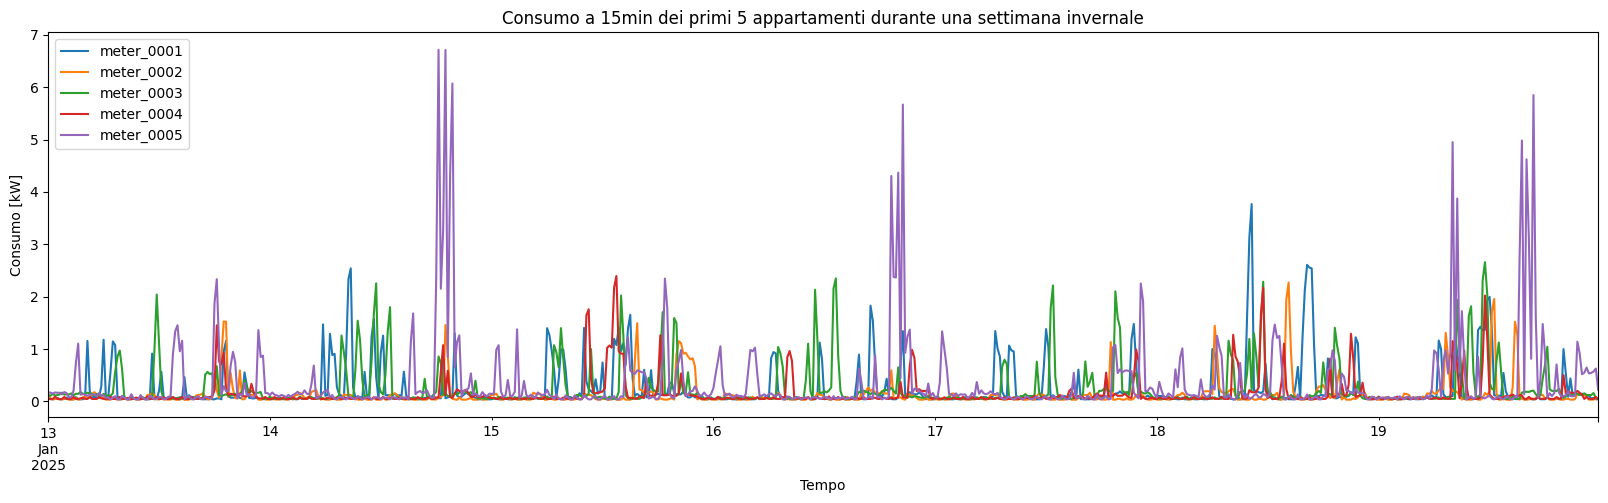

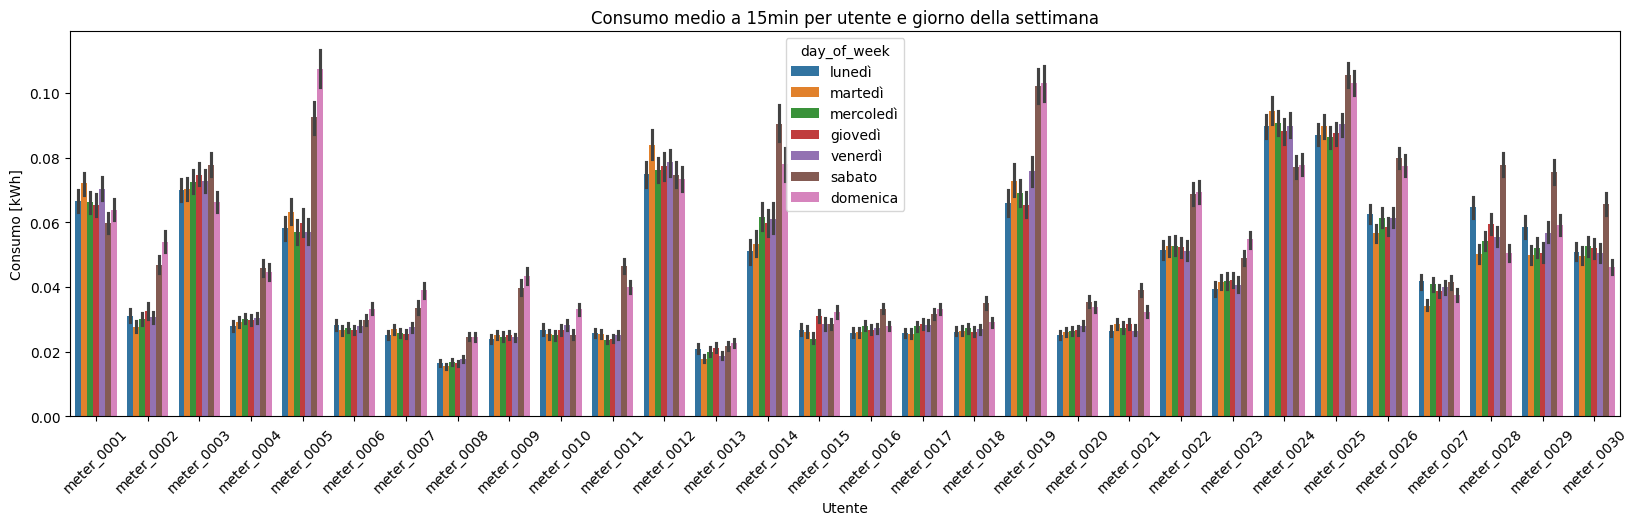

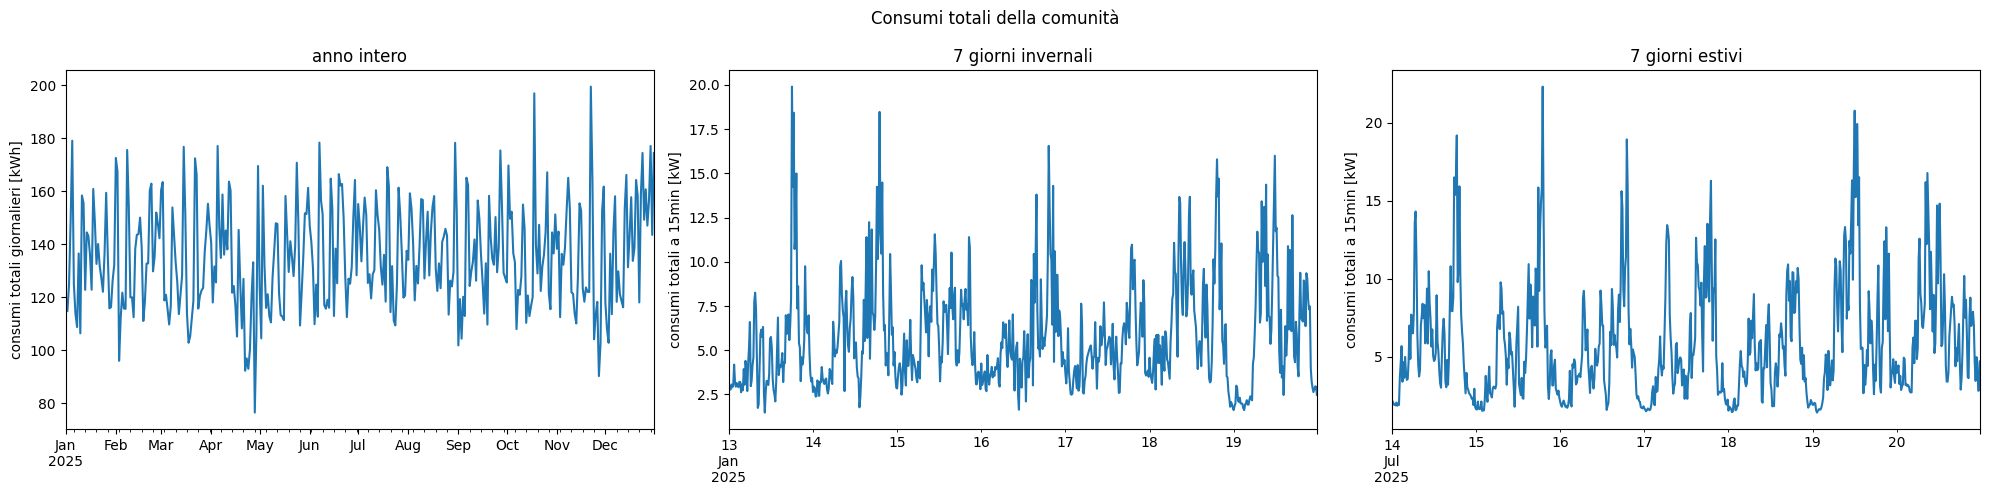

<IPython.core.display.Javascript object>

In [2]:
#@title ▶️ Codice per esplorazione dei dati di consumo ▶️
consumption = pd.read_csv('dati_consumo_15min.csv', header=0, parse_dates=[0], index_col=0).tz_localize('Etc/GMT-1')
consumption_lifetime = pd.DataFrame(np.tile(consumption, (life_span, 1)), index=pd.date_range(start=consumption.index[0], periods=len(consumption)*life_span, freq='15min'), columns=consumption.columns)
display(consumption_lifetime)

fig, ax = plt.subplots(1,1,figsize=(20,5))
(consumption*4).iloc[(consumption.index >= '2025-01-13 00:00:00') & (consumption.index<'2025-01-20 00:00:00'), :5].plot(ax=ax)
ax.set_title('Consumo a 15min dei primi 5 appartamenti durante una settimana invernale')
ax.set_xlabel('Tempo')
ax.set_ylabel('Consumo [kW]')
ax.legend()

fig, ax = plt.subplots(figsize=(20,5))
cons = consumption.copy()
cons['time'] = cons.index
cons_melt = cons.melt(var_name='utente', value_name='consumo', id_vars='time')
days = ['lunedì', 'martedì', 'mercoledì', 'giovedì', 'venerdì', 'sabato', 'domenica']
cons_melt['day_of_week'] = cons_melt['time'].dt.dayofweek.map(lambda x: days[x])
sns.barplot(x='utente', y='consumo', hue='day_of_week', data=cons_melt, hue_order=days,ax=ax)
ax.set_title('Consumo medio a 15min per utente e giorno della settimana')
ax.set_xlabel('Utente')
ax.set_ylabel('Consumo [kWh]')
ax.tick_params(axis='x', rotation=45)

fig, ax = plt.subplots(1,3,figsize=(20,5))
tot_consumption = consumption.sum(axis=1)
#suptitle consumi totali
fig.suptitle('Consumi totali della comunità')
tot_consumption.resample('1D').sum().plot(ax=ax[0])
ax[0].set_title('anno intero')
ax[0].set_ylabel('consumi totali giornalieri [kWh]')
(tot_consumption*4)[(tot_consumption.index >= '2025-01-13 00:00:00') & (tot_consumption.index<'2025-01-20 00:00:00')].plot(ax=ax[1])
ax[1].set_title('7 giorni invernali')
ax[1].set_ylabel('consumi totali a 15min [kW]')
(tot_consumption*4)[(tot_consumption.index >= '2025-07-14 00:00:00') & (tot_consumption.index<'2025-07-21 00:00:00')].plot(ax=ax[2])
ax[2].set_title('7 giorni estivi')
ax[2].set_ylabel('consumi totali a 15min [kW]')
plt.tight_layout()
plt.show()

display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 5000})'''))

# 3. Tariffa dinamica

In questa sezione caricheremo una **simulazione della [tariffa dinamica di AEM](https://aemsa.ch/it/news/tariffa-dinamica-aem)**, in modo da poter esplorare la sua applicazione ai locatari per la parte di energia prelevata dalla rete.

> ⚠️ *Nota: si tratta di una simulazione a scopo didattico, non della tariffa ufficiale attualmente in vigore.*

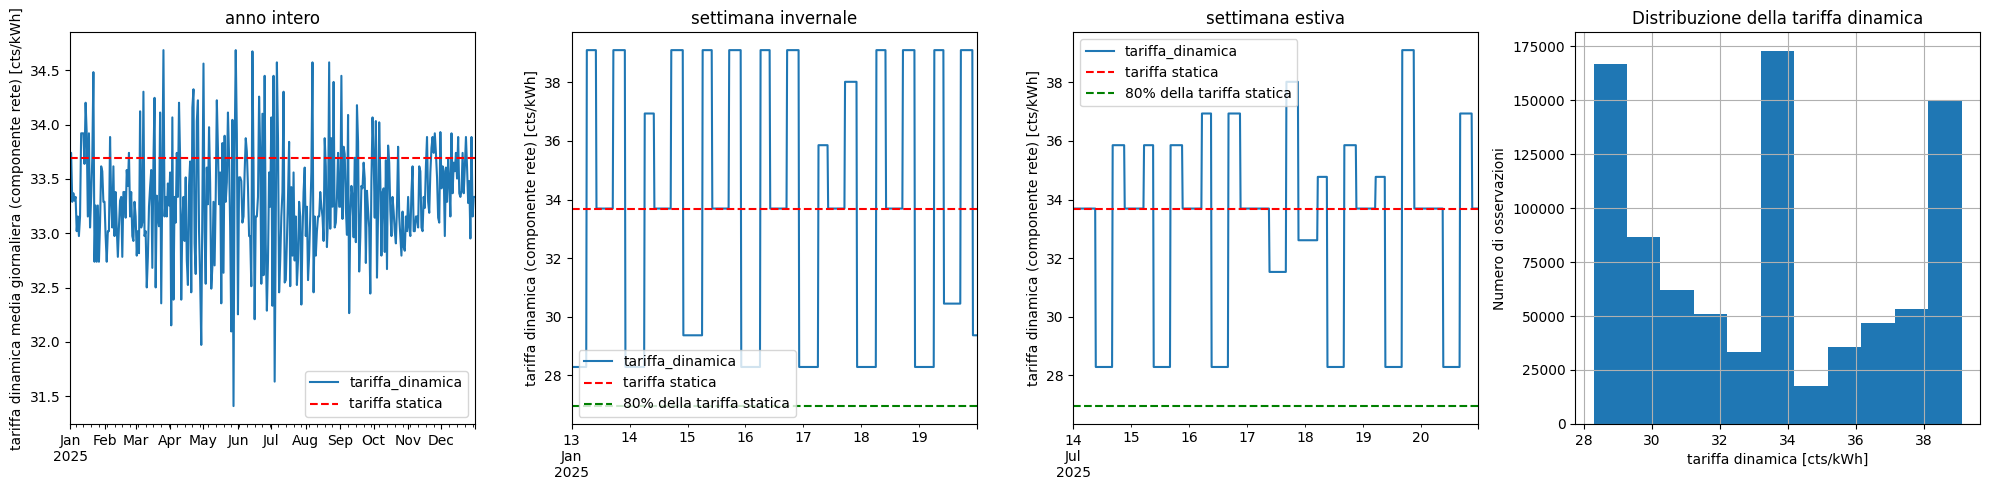

In [3]:
#@title ▶️ Codice per il caricamento e l'esplorazione della tariffa dinamica ▶️
tariffa_rete_dinamica = pd.read_csv('tariffa_dinamica.csv', header=0, parse_dates=[0], index_col=0).squeeze().tz_localize('Etc/GMT-1')
# display(tariffa_dinamica.head())
tariffa_dinamica = (31.17- 10.83 + tariffa_rete_dinamica) * 1.081
tariffa_statica = 31.17 * 1.081

fig, ax = plt.subplots(1,4,figsize=(20,5))
tariffa_dinamica[tariffa_dinamica.index.year == 2025].resample('1D').mean().plot(ax=ax[0])
ax[0].axhline(tariffa_statica, color='r', linestyle='--', label='tariffa statica')
# ax[0].axhline(tariffa_statica*0.8, color='g', linestyle='--', label='80% della tariffa statica')
ax[0].set_title('anno intero')
ax[0].set_ylabel('tariffa dinamica media giornaliera (componente rete) [cts/kWh]')
ax[0].legend()
tariffa_dinamica[(tariffa_dinamica.index >= '2025-01-13 00:00:00') & (tariffa_dinamica.index<'2025-01-20 00:00:00')].plot(ax=ax[1])
ax[1].axhline(tariffa_statica, color='r', linestyle='--', label='tariffa statica')
ax[1].axhline(tariffa_statica*0.8, color='g', linestyle='--', label='80% della tariffa statica')
ax[1].set_title('settimana invernale')
ax[1].set_ylabel('tariffa dinamica (componente rete) [cts/kWh]')
ax[1].legend()
tariffa_dinamica[(tariffa_dinamica.index >= '2025-07-14 00:00:00') & (tariffa_dinamica.index<'2025-07-21 00:00:00')].plot(ax=ax[2])
ax[2].axhline(tariffa_statica, color='r', linestyle='--', label='tariffa statica')
ax[2].axhline(tariffa_statica*0.8, color='g', linestyle='--', label='80% della tariffa statica')
ax[2].set_title('settimana estiva')
ax[2].set_ylabel('tariffa dinamica (componente rete) [cts/kWh]')
ax[2].legend()
tariffa_dinamica.hist(ax=ax[3], bins=len(tariffa_dinamica.unique()))
ax[3].set_title('Distribuzione della tariffa dinamica')
ax[3].set_xlabel('tariffa dinamica [cts/kWh]')
ax[3].set_ylabel('Numero di osservazioni')
plt.tight_layout()

# 4. Dimensionamento e orientamento dell'impianto PV

In questa sezione caricheremo il **profilo di produzione di un impianto fotovoltaico (PV)** simulato sull’intera durata di vita del sistema. La simulazione assume un **degrado progressivo** dell’impianto, pari al **20% dopo 25 anni** (ovvero, alla fine della vita utile l’impianto produce l’80% rispetto alla produzione iniziale).

---
## Utilizzo
È possibile selezionare:
- la **dimensione dell’impianto** (in kWp),
- l’**azimuth** dei moduli.

Il **tilt** dei moduli è invece fissato a **13°** per tutte le simulazioni.

<br>

⚠️**Ricordatevi di eseguire la cella prima di cambiare i parametri**⚠️


In [4]:
#@title ▶️ Codice per calcolo profilo PV ▶️
pv_profile_south = pd.read_csv('energia_pv_sud.csv', header=0, parse_dates=[0], index_col=0).squeeze().tz_localize('Etc/GMT-1')
pv_profile_east_west = (pd.read_csv('energia_pv_est.csv', header=0, parse_dates=[0], index_col=0).squeeze().tz_localize('Etc/GMT-1')+
                        pd.read_csv('energia_pv_ovest.csv', header=0, parse_dates=[0], index_col=0).squeeze().tz_localize('Etc/GMT-1'))/2

class PVProfileCalculator:
    def __init__(self, south_df, east_west_df, init_orient='sud', init_size=50):
      self.south = south_df
      self.east_west = east_west_df
      self.profile = None
      self.size = None
      self.orientation = None

      # creo i controlli
      slider_kwargs = dict(style={'description_width': '33%'}, layout=Layout(width='30%'))

      self.orient = widgets.RadioButtons(
          options=['sud', 'est-ovest'],
          description='orientamento PV:',
          value=init_orient,
          **slider_kwargs
      )

      self.size_slider = widgets.SelectionSlider(
          options=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200],
          value=init_size,
          description='dimensione PV [kWp]:',
          continuous_update=False,   # only trigger on release
          **slider_kwargs
          )

      # costruisco e mostro l'interattività
      self.widget = interactive(self._update_plot,
                                orientamento_pv=self.orient,
                                dimensionamento_pv=self.size_slider)
      display(self.widget)

    def _disable_controls(self):
      self.orient.disabled = True
      self.size_slider.disabled = True

    def _enable_controls(self):
      self.orient.disabled = False
      self.size_slider.disabled = False

    def _update_plot(self, orientamento_pv, dimensionamento_pv):
      try:
        # Disabilita i controlli durante l'elaborazione
        self._disable_controls()

        self.size = dimensionamento_pv
        self.orientation = orientamento_pv
        # scelgo il profilo e lo salvo nell'attributo
        if orientamento_pv == 'sud':
            profile = self.south * dimensionamento_pv
        else:
            profile = self.east_west * dimensionamento_pv

        self.profile = profile.copy()

        # aggrego e plotto il 2025
        daily_2025 = (
            profile[profile.index.year == 2025]
                    .resample('1D')
                    .sum()
        )

        fig, ax = plt.subplots(1,3,figsize=(20,5))
        daily_2025.plot(ax=ax[0])
        ax[0].set_title('Produzione giornaliera PV (2025)')
        ax[0].set_ylabel('kWh')
        max_p = profile.max() * 4
        (profile*4)[(profile.index >= '2025-01-13') & (profile.index < '2025-01-20')].plot(ax=ax[1])
        ax[1].set_title('Produzione PV (settimana invernale)')
        ax[1].set_ylabel('kW')
        ax[1].set_ylim(0, max_p)
        (profile*4)[(profile.index >= '2025-07-14')&(profile.index < '2025-07-21')].plot(ax=ax[2])
        ax[2].set_title('Produzione PV (settimana estiva)')
        ax[2].set_ylabel('kW')
        ax[2].set_ylim(0, max_p)
        plt.tight_layout()
        plt.show()
      finally:
        # Riabilita sempre i controlli, anche in caso di errore
        self._enable_controls()

    def get_profile(self):
      return self.profile.copy()

    def get_pv_size(self):
      return self.size

    def get_orientation(self):
      return self.orientation


# grab old settings if present
try:
    last_orient = pv_plant.get_orientation()
    last_size   = pv_plant.get_pv_size()
except NameError:
    last_orient, last_size = 'sud', 50


pv_plant = PVProfileCalculator(pv_profile_south, pv_profile_east_west, last_orient, last_size)

interactive(children=(RadioButtons(description='orientamento PV:', layout=Layout(width='30%'), options=('sud',…

# 5. Profili EV

Progettare un impianto fotovoltaico oggi significa considerare che, salvo imprevisti, esso produrrà energia per i prossimi **25–30 anni**. È quindi fondamentale tenere conto dell'evoluzione dei consumi elettrici nel tempo durante la fase di dimensionamento, visto che la quota di autoconsumo influenza considerevolmente la redditività dell'impianto.

In particolare, la Svizzera si è impegnata nell’elettrificazione del trasporto privato su gomma, e si prevede che in futuro il **parco veicoli elettrici (EV)** aumenterà in modo significativo. Questo comporterà un incremento dei consumi elettrici nelle palazzine simulate.

---
## Scenari

### Scenari di penetrazione EV

Secondo le statistiche, in media per **30 appartamenti** in edifici plurifamiliari in Ticino ci sono **39 automobili**. Supponiamo che questo numero rimanga costante nel tempo e stimiamo quante di queste diventeranno elettriche nel corso degli anni.

Facciamo riferimento a due scenari tratti dalle [**Prospettive Energetiche 2050+**](https://www.bfe.admin.ch/bfe/it/home/politica/prospettive-energetiche-2050-plus.html):

- **ZERO BASIS**: scenario base che prevede il raggiungimento dell’obiettivo di azzeramento delle emissioni di gas serra entro il 2050.
- **WWB (Weiter Wie Bisher)**: scenario *business as usual*, in cui gli obiettivi non vengono raggiunti e la penetrazione degli EV è più lenta.
- **Nessun EV**: Scenario in cui non è permessa la ricarica EV nelle palazzine.

#### Penetrazione attesa di EV nel tempo

| Anno | ZERO BASIS | WWB |
|------|------------|-----|
| 2025 | 3%         | 3%  |
| 2030 | 10%        | 7%  |
| 2035 | 22%        | 13% |
| 2040 | 39%        | 21% |
| 2045 | 55%        | 29% |
| 2050 | 68%        | 37% |

### Scenari di ricarica

Simuleremo quattro strategie di ricarica dei veicoli elettrici:

1. **Carica il prima possibile**: appena l’auto è collegata, la ricarica parte immediatamente.
2. **Carica solo da PV**: l’auto viene caricata solo quando c’è surplus di produzione fotovoltaica.
3. **Carica in tariffa dinamica bassa**: l’auto si carica solo nelle ore con prezzo dinamico basso.
4. **Carica da PV e in tariffa dinamica bassa**: si carica sia da PV, che quando il prezzo è basso.

### Limitazione della potenza massima di prelievo

Infine, esploreremo la possibilità di applicare una limitazione del **prelievo massimo di potenza** dalle tre palazzine, attraverso una logica di controllo che fissi una soglia aggregata:

- **22 kW** (equivalente a 32 A trifase)
- **44 kW** (equivalente a 63 A trifase)
- **Nessuna limitazione**

Il controllo limiterà la potenza di ricarica delle auto per evitare si superare i limiti.

⚠️**Ricordatevi di eseguire la cella prima di cambiare i parametri**⚠️

In [5]:
#@title ▶️ Codice per la scelta degli EV ▶️
ev_penetrations_years = [2025, 2030, 2035, 2040, 2045, 2050]
ev_penetrations = {'ZERO_BASIS': [0.03, 0.10, 0.22, 0.39, 0.55, 0.68],
                   'WWB': [0.03, 0.07, 0.13, 0.21, 0.29, 0.37]}
ev_penetration_interpolators = {}
for scenario, penetration_values in ev_penetrations.items():
    ev_penetration_interpolators[scenario] = PchipInterpolator(ev_penetrations_years, penetration_values)

num_ev_in_building = 39

norm = Normalize(vmin=tariffa_dinamica.min(), vmax=tariffa_dinamica.max())
cmap = colormaps['bwr']
sm = ScalarMappable(cmap=cmap, norm=norm)

def plot_ev_profile(ax, tariffa_dinamica, tot_ev_profile, mask):

    tariff = tariffa_dinamica.loc[mask]
    profile = tot_ev_profile.loc[mask]
    dates = tariff.index
    vals  = tariff.values

    for i in range(len(dates)-1):
        t0 = dates[i]
        t1 = dates[i+1]
        color = cmap(norm(vals[i]))
        ax.axvspan(t0, t1, facecolor=color, alpha=0.3, edgecolor='none')
    ax.plot(profile, color='black', label='Profilo EV')
    ax.set_xlim(dates[0], dates[-1])
    ax.legend(loc='upper right')

class EVProfileLoader:
    def __init__(self, pv_plant, init_scenario='ZERO_BASIS', init_algo='carica il prima possibile', init_p_max='Nessun limite'):
      self.pv_plant = pv_plant
      self.profile = None

      # creo i controlli
      slider_kwargs = dict(style={'description_width': '55%'}, layout=Layout(width='66%'))
      self.scenario = widgets.RadioButtons(
          options=['ZERO_BASIS', 'WWB', 'Nessun EV'],
          value=init_scenario,
          description='Scenario di penetrazione EV:',
          **slider_kwargs
      )
      self.algo = widgets.RadioButtons(
          options=['carica il prima possibile', 'carica solo da PV', 'carica con tariffa bassa', 'carica da PV e con tariffa bassa'],
          value=init_algo,
          description='Scenario di carica:',
          **slider_kwargs
      )

      self.p_max = widgets.RadioButtons(
          options=['22kW', '44kW', 'Nessun limite'],
          value=init_p_max,
          description='Corrente massima di prelievo della palazzina:',
          **slider_kwargs
      )

      # costruisco e mostro l'interattività
      self.widget = interactive(self._load_profile,
                                scenario=self.scenario,
                                algo=self.algo,
                                p_max=self.p_max)
      display(self.widget)

    def _disable_controls(self):
      self.scenario.disabled = True
      self.algo.disabled = True
      self.p_max.disabled = True

    def _enable_controls(self):
      self.scenario.disabled = False
      self.algo.disabled = False
      self.p_max.disabled = False

    def _load_profile(self, scenario, algo, p_max):
      try:
        # Disable controls while processing
        self._disable_controls()

        size = self.pv_plant.get_pv_size()
        orientation = self.pv_plant.get_orientation()
        algo_dict = {
            'carica il prima possibile': 'asap',
            'carica solo da PV': 'solar',
            'carica con tariffa bassa': 'tariffa_dinamica',
            'carica da PV e con tariffa bassa': 'tariffa_dinamica_solar'
        }

        p_max_dict = {
            '22kW': 22,
            '44kW': 44,
            'Nessun limite': 1000
        }

        p_max = p_max_dict[p_max]
        algo = algo_dict[algo]
        if scenario == 'Nessun EV':
          self.profile = pd.DataFrame(index=consumption_lifetime.index, columns=consumption_lifetime.columns, data=0.0)
        else:
          try:
            filename_profile = f'sas/{algo}/{scenario}/{orientation}/{int(size)}kWp/{p_max}kW/ev_profiles.parquet'
            profile = pd.read_parquet(filename_profile)
            filename_unserved = f'sas/{algo}/{scenario}/{orientation}/{int(size)}kWp/{p_max}kW/percent_unserved_charge.parquet'
            percent_unserved = pd.read_parquet(filename_unserved)
          except FileNotFoundError:
            print('Profilo non trovato')
            # Re-enable controls and exit the function
            self._enable_controls()
            return
          self.profile = profile

        # profili_ev = consumption_lifetime.copy() * 0.0
        # display(ev_profile.profile)
        # plot one week in winter and one in summer of the first and the last year
        tot_ev_profile = self.profile.sum(axis=1)*4
        fig, ax = plt.subplots(1,figsize=(20,2))
        years = np.arange(2025,2025+life_span)
        if scenario != 'Nessun EV':
          ax.plot(years, np.round(39 * ev_penetration_interpolators[scenario](years)))
        else:
          ax.plot(years, np.zeros_like(years))
        ax.set_title(f'Numero di EV attesi nella comunità nel tempo ({scenario})')
        ax.set_xlabel('Anno')
        ax.set_ylabel('Numero di EV')
        ax.set_xticks(years)
        ax.grid('on')
        plt.show()
        fig, ax = plt.subplots(2,2,figsize=(20,5))
        mask = (tot_ev_profile.index >= '2025-01-13') & (tot_ev_profile.index<'2025-01-20') & (tot_ev_profile.index.year == 2025)
        plot_ev_profile(ax[0,0], tariffa_dinamica, tot_ev_profile, mask)
        ax[0,0].set_title('7 giorni invernali primo anno')
        ax[0,0].set_ylabel('Consumo [kW]')

        mask = (tot_ev_profile.index >= '2025-07-14') & (tot_ev_profile.index<'2025-07-21') & (tot_ev_profile.index.year == 2025)
        plot_ev_profile(ax[0,1], tariffa_dinamica, tot_ev_profile, mask)
        ax[0,1].set_title('7 giorni estivi primo anno')
        ax[0,1].set_ylabel('Consumo [kW]')

        mask = (tot_ev_profile.index >= '2049-01-13') & (tot_ev_profile.index<'2049-01-20') & (tot_ev_profile.index.year == 2049)
        plot_ev_profile(ax[1,0], tariffa_dinamica, tot_ev_profile, mask)
        ax[1,0].set_title('7 giorni invernali ultimo anno')
        ax[1,0].set_ylabel('Consumo [kW]')

        mask = (tot_ev_profile.index >= '2049-07-14') & (tot_ev_profile.index<'2049-07-21') & (tot_ev_profile.index.year == 2049)
        plot_ev_profile(ax[1,1], tariffa_dinamica, tot_ev_profile, mask)
        ax[1,1].set_title('7 giorni estivi ultimo anno')
        ax[1,1].set_ylabel('Consumo [kW]')

        plt.tight_layout()

        # Make room for the colorbar
        plt.subplots_adjust(right=0.88)

        # Add colorbar for the tariff
        cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
        cbar = fig.colorbar(sm, cax=cbar_ax)
        cbar.set_label('Tariffa Dinamica [cts/kWh]')

        if scenario != 'Nessun EV':
          fig, ax = plt.subplots(1,1,figsize=(20,3))
          percent_unserved.plot(kind='bar', ax=ax, legend=None)
          ax.set_title('Percentuale di carica non servita')
          ax.set_xlabel('ID EV')
          ax.set_ylabel('%')
          ax.set_ylim(0, 100)
          ax.grid('on')

        plt.show()
      finally:
        # Always re-enable controls, even if an error occurs
        self._enable_controls()

    def get_profile(self):
      return self.profile.copy()


try:
  last_scenario = ev_profile_loader.scenario.value
  last_algo = ev_profile_loader.algo.value
  last_p_max = ev_profile_loader.p_max.value
except NameError:
    last_scenario, last_algo, last_p_max = 'ZERO_BASIS', 'carica il prima possibile', 'Nessun limite'

ev_profile_loader = EVProfileLoader(pv_plant, last_scenario, last_algo, last_p_max)

display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 5000})'''))

interactive(children=(RadioButtons(description='Scenario di penetrazione EV:', layout=Layout(width='66%'), opt…

<IPython.core.display.Javascript object>

#6. Calcolo dei flussi risultanti

⚠️ **Esegui il codice prima di continuare** ⚠️

<IPython.core.display.Javascript object>

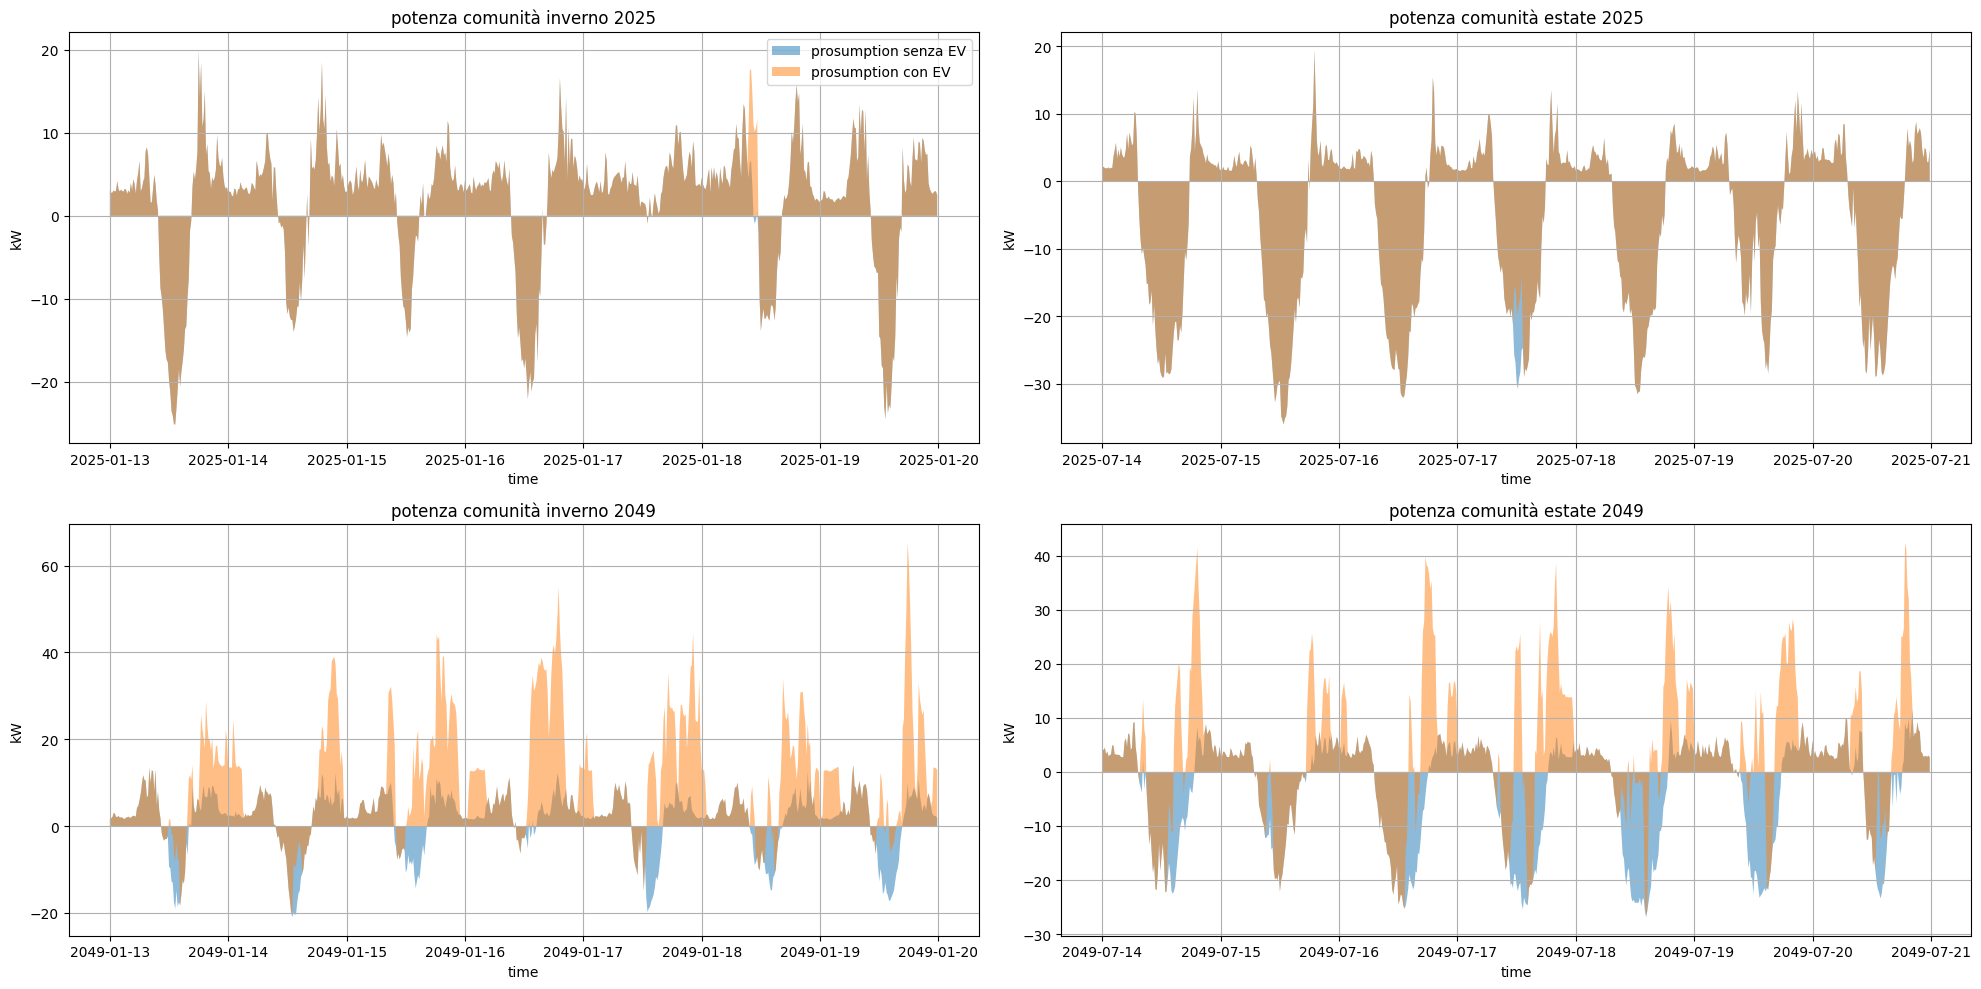

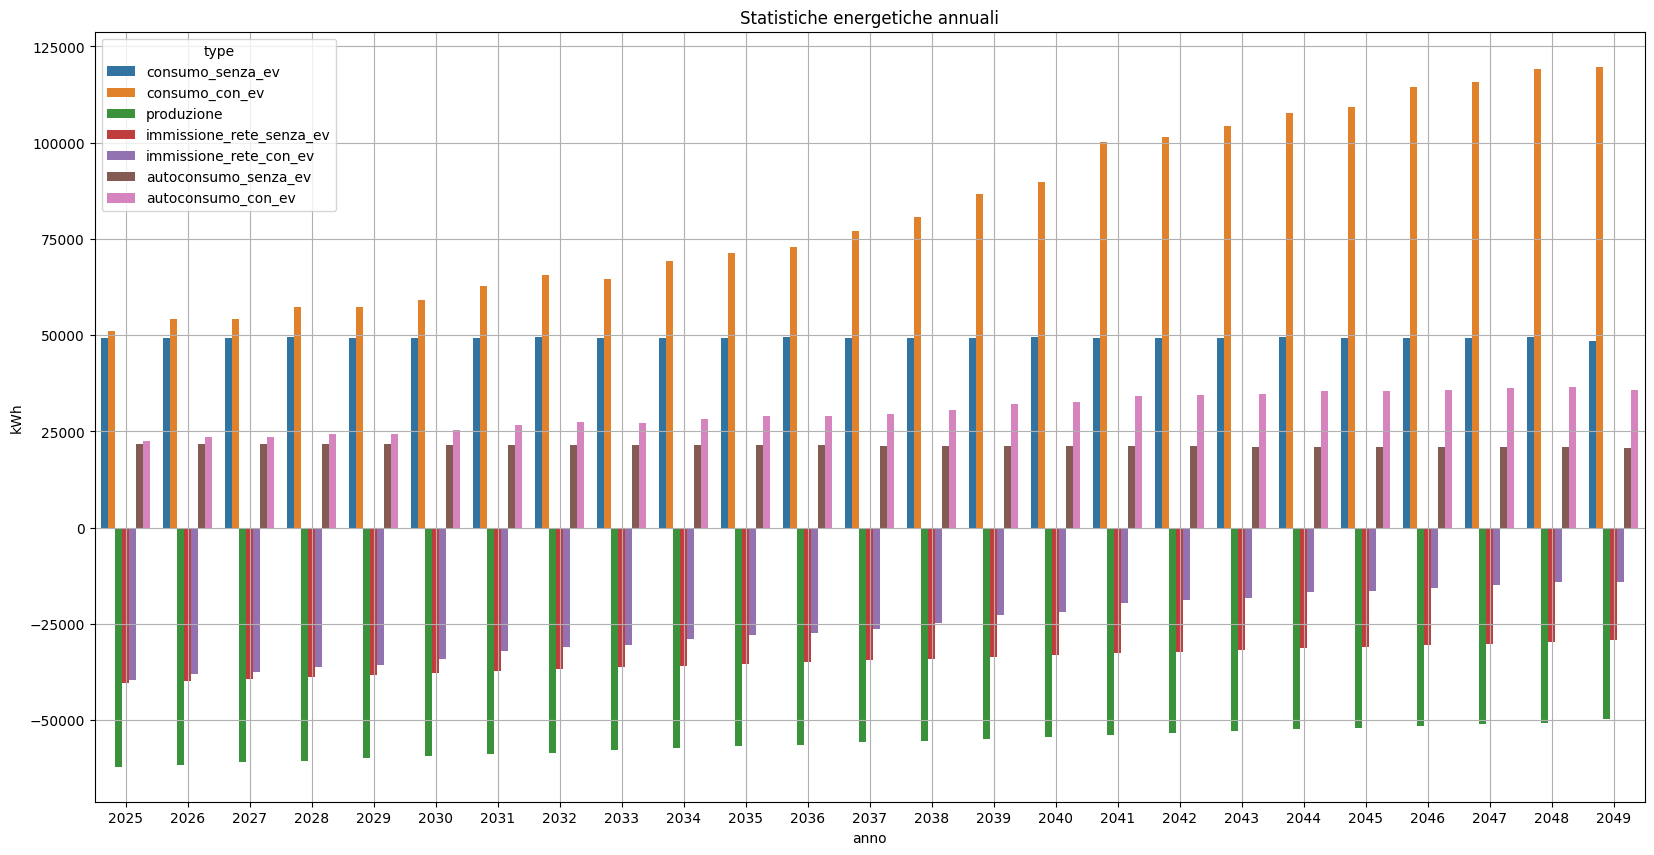

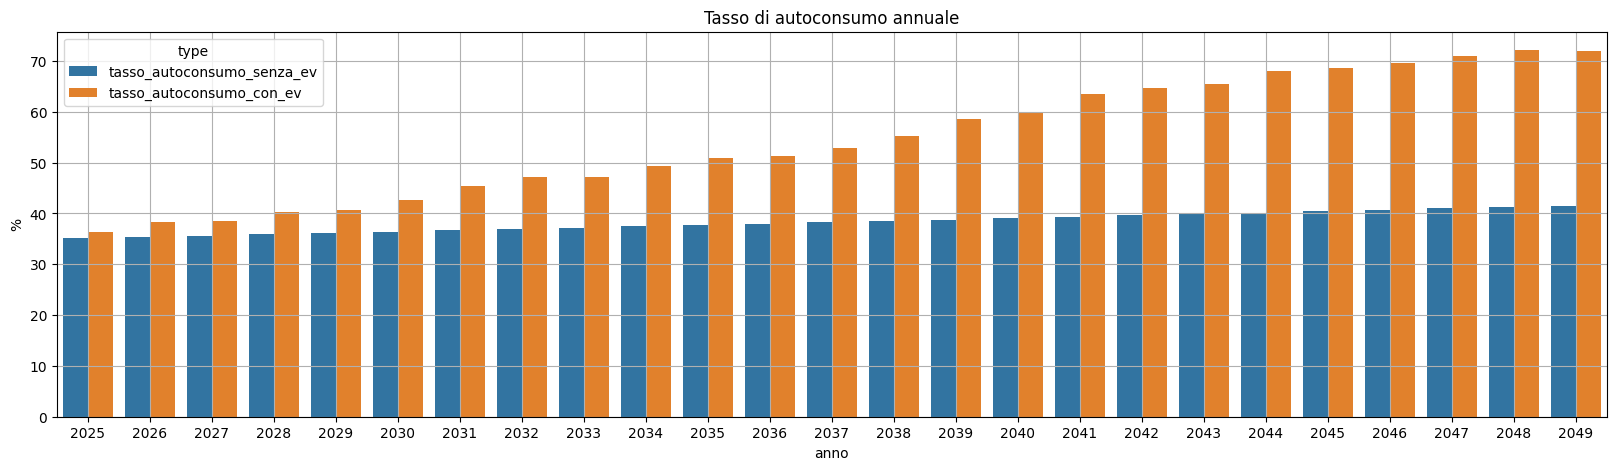

In [6]:
#@title ▶️ Codice per calcolo dei flussi risultanti ▶️

ev_profile = ev_profile_loader.get_profile()
consumption_ev = consumption_lifetime*0.0
evs = list(ev_profile.columns)
meters = list(consumption_ev.columns)

# Ensure that there are enough meter slots for all EVs.
if len(evs) > 2 * len(meters):
    raise ValueError("There are more EVs than available meter slots (max 2 EVs per meter).")

# Create a list that repeats each meter twice (each meter has 2 slots).
meter_slots = meters * 2

#set random seed
np.random.seed(42)

# Shuffle the meter slot list.
np.random.shuffle(meter_slots)

# Assign each EV a meter from the first len(evs) elements.
ev_to_meter = {ev: meter_slots[i] for i, ev in enumerate(evs)}
meter_assigned_ev = pd.DataFrame(index=meters, columns=['num_evs', 'year_ev_1', 'year_ev_2', 'ev_1', 'ev_2'])
meter_assigned_ev['num_evs'] = 0
for ev in evs:
  meter = ev_to_meter[ev]
  # print(f'ev {ev} assegnato al contatore {meter}')
  consumption_ev[meter] += ev_profile[ev]
  if meter_assigned_ev.loc[meter, 'num_evs'] == 0:
    #get the year of the first non-zero point
    if (ev_profile[ev] != 0).any():
      meter_assigned_ev.loc[meter, 'year_ev_1'] = ev_profile[ev][ev_profile[ev] != 0].index[0].year
      meter_assigned_ev.loc[meter, 'num_evs'] += 1
      meter_assigned_ev.loc[meter, 'ev_1'] = ev
  elif meter_assigned_ev.loc[meter, 'num_evs'] == 1:
    if (ev_profile[ev] != 0).any():
      meter_assigned_ev.loc[meter, 'year_ev_2'] = ev_profile[ev][ev_profile[ev] != 0].index[0].year
      meter_assigned_ev.loc[meter, 'num_evs'] += 1
      meter_assigned_ev.loc[meter, 'ev_2'] = ev
# display(meter_assigned_ev)

tot_consumption_lifetime = consumption_lifetime.sum(axis=1)
consumption_lifetime_ev = consumption_lifetime + consumption_ev
tot_consumption_lifetime_ev = consumption_lifetime_ev.sum(axis=1)
production_lifetime = pv_plant.get_profile()
energy_ratio_users = consumption_lifetime_ev / consumption_lifetime_ev.sum(axis=1).values.reshape(-1, 1)

prosumption_lifetime_no_ev = tot_consumption_lifetime - production_lifetime
prosumption_lifetime = tot_consumption_lifetime_ev - production_lifetime

prosumption_lifetime_no_ev.name = 'prosumption senza EV'
prosumption_lifetime.name = 'prosumption con EV'

# calculate yearly values for FCF calculation
yearly_production = production_lifetime.groupby(production_lifetime.index.year).sum()
yearly_grid_injection_no_ev = prosumption_lifetime_no_ev.groupby(prosumption_lifetime_no_ev.index.year).apply(lambda x: -x[x < 0].sum())
yearly_self_consumed_no_ev = yearly_production - yearly_grid_injection_no_ev
yearly_grid_injection = prosumption_lifetime.groupby(prosumption_lifetime.index.year).apply(lambda x: -x[x < 0].sum())
yearly_self_consumed = yearly_production - yearly_grid_injection


def plot_df(ax, s_ev, s_no_ev, title, y_label, season=None, year=None):
  if season == 'winter':
    mask = (s_ev.index >= f'{year}-01-13 00:00:00') & (s_ev.index < f'{year}-01-20 00:00:00')
    title += f' inverno {year}'
  elif season == 'summer':
    mask = (s_ev.index >= f'{year}-07-14 00:00:00') & (s_ev.index < f'{year}-07-21 00:00:00')
    title += f' estate {year}'
  else:
    # use all the data available
    mask = np.ones(len(s_ev), dtype=bool)

  ax.fill_between(s_ev.index[mask], s_ev[mask], 0, alpha=0.5, label=s_ev.name)
  ax.fill_between(s_no_ev.index[mask], s_no_ev[mask], 0, alpha=0.5, label=s_no_ev.name)
  ax.set_title(title)
  ax.set_xlabel('time')
  ax.set_ylabel(y_label)
  ax.grid('on')


fig, ax = plt.subplots(2,2,figsize=(20,10))
plot_df(ax[0,0], prosumption_lifetime_no_ev*4, prosumption_lifetime*4, 'potenza comunità', 'kW', 'winter', 2025)
plot_df(ax[0,1], prosumption_lifetime_no_ev*4, prosumption_lifetime*4, 'potenza comunità', 'kW', 'summer', 2025)
plot_df(ax[1,0], prosumption_lifetime_no_ev*4, prosumption_lifetime*4, 'potenza comunità', 'kW', 'winter', 2049)
plot_df(ax[1,1], prosumption_lifetime_no_ev*4, prosumption_lifetime*4, 'potenza comunità', 'kW', 'summer', 2049)
ax[0, 0].legend()
plt.tight_layout()


yearly_stats = pd.DataFrame(
    index=np.arange(2025, 2025 + life_span),
    columns=[
        'consumo_senza_ev', 'consumo_con_ev', 'produzione',
        'immissione_rete_senza_ev', 'immissione_rete_con_ev',
        'autoconsumo_senza_ev', 'autoconsumo_con_ev',
        'anno'
    ],
    dtype=float
)

yearly_stats['consumo_senza_ev'] = tot_consumption_lifetime.groupby(tot_consumption_lifetime.index.year).sum()
yearly_stats['consumo_con_ev'] = tot_consumption_lifetime_ev.groupby(tot_consumption_lifetime_ev.index.year).sum()
yearly_stats['immissione_rete_senza_ev'] = -yearly_grid_injection_no_ev
yearly_stats['immissione_rete_con_ev'] = -yearly_grid_injection
yearly_stats['autoconsumo_senza_ev'] = yearly_self_consumed_no_ev
yearly_stats['autoconsumo_con_ev'] = yearly_self_consumed
yearly_stats['produzione'] = -yearly_production
yearly_stats['anno'] = yearly_stats.index

# Reset dell’indice per avere 'anno' come colonna normale
yearly_stats = yearly_stats.reset_index(drop=True)

fig, ax = plt.subplots(1,1,figsize=(20,10))
yearly_stats_melted = yearly_stats.melt(var_name='type', value_name='value', id_vars='anno')
sns.barplot(x='anno', y='value', hue='type', data=yearly_stats_melted, ax=ax)
ax.set_title('Statistiche energetiche annuali')
ax.set_ylabel('kWh')
ax.grid('on')

fig, ax = plt.subplots(1,1,figsize=(20,5))
df_sc = pd.DataFrame({'anno': yearly_stats['anno'], 'tasso_autoconsumo_senza_ev': -yearly_stats['autoconsumo_senza_ev'] / yearly_stats['produzione'] * 100,
                      'tasso_autoconsumo_con_ev': -yearly_stats['autoconsumo_con_ev'] / yearly_stats['produzione'] * 100})
df_sc_melted = df_sc.melt(var_name='type', value_name='value', id_vars='anno')
sns.barplot(x='anno', y='value', hue='type', data=df_sc_melted, ax=ax)
ax.set_title('Tasso di autoconsumo annuale')
ax.set_ylabel('%')
ax.grid('on')
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 5000})'''))

# 7. Stima del ritorno sull'investimento per l'impianto fotovoltaico

In questa sezione stimiamo il **ritorno sull'investimento (ROI)** di un impianto fotovoltaico, sulla base di un’analisi finanziaria semplificata.

## Dati utilizzati

Per questa analisi prendiamo in considerazione i seguenti elementi:

- ⚡ **Profilo di energia immessa** nella comunità energetica e nella rete (calcolato nelle sezioni precedenti)  
- 💰 **Costo iniziale dell’impianto fotovoltaico (CAPEX) al netto degli incentivi**  
- 🔧 **Costi operativi annuali (OPEX = O&M + costi amministrativi)**  
- 🧾 **Costi di misurazione, contabilizzazione e gestione amministrativa**  
- 💸 **Prezzi di vendita e acquisto dell’energia**  
- 🏦 **Tasso di sconto (costo del capitale)**  
- 📆 **Durata prevista dell’impianto**: 25 anni  

> *Nota: questa è un'analisi semplificata, che non considera l’IVA né eventuali risparmi fiscali.*

---

## Metodologia

### 1. Calcolo dei **costi** e dei **ricavi** annuali

- **Ricavi**: vendita dell’energia immessa nella rete o venduta all’interno della comunità.  
- **Costi**: investimento iniziale (CAPEX a $t = 0$) e costi operativi annui (OPEX: O&M + contabilizzazione).

### 2. Stima dei **flussi di cassa netti** per ogni anno

$$
\mathrm{FCF} \;=\; \mathrm{Ricavi} - \mathrm{OPEX}
$$  


### 3. Calcolo del **Valore Attuale Netto (NPV)**

Il **Valore Attuale Netto** misura il valore attuale dei flussi di cassa futuri scontati a un determinato tasso di rendimento.

$$
\mathrm{NPV}(i, N) \;=\; \sum_{t=0}^{N} \frac{\mathrm{FCF}_t}{(1 + i)^t}
$$

con
- $\mathrm{FCF}_t$: flusso di cassa netto al tempo \( t \)  
- $i$: tasso di sconto (costo del capitale)  
- $N$: durata del progetto (in anni)    


### 4. Calcolo del **Tasso Interno di Rendimento (IRR)**

L’**IRR** è il tasso di sconto che rende il valore attuale netto pari a zero:

$$
\mathrm{NPV}(\mathrm{IRR}, N) = 0
$$

<br>

⚠️**Ricordati di eseguire la cella prima di cambiare i parametri** ⚠️

In [7]:
#@title ▶️ Codice per calcolo del rientro dell'investimento ▶️
class PVPlantBankability:
    """Interactive NPV / IRR / discounted payback calculator for a PV plant"""

    def __init__(
        self,
        south_df: pd.DataFrame,
        east_west_df: pd.DataFrame,
        yearly_grid_injection: pd.Series,
        yearly_self_consumed: pd.Series,
        pv_plant,
        life_span: int = 25,
        init_o_and_m: float = 30,
        init_accounting_costs: float = 1000,
        init_wacc: float = 2.5,
        init_p_sell_dso: float = 7.5,
        init_p_sell_com: float = 0,
        init_capex: float = 0,
    ):
        # --- dati esterni ---------------------------------------------------
        self.south = south_df
        self.east_west = east_west_df
        self.yearly_grid_injection = yearly_grid_injection  # [kWh/a]
        self.yearly_self_consumed = yearly_self_consumed    # [kWh/a]
        self.pv_plant = pv_plant
        self.life_span = life_span

        self.plant_size = self.pv_plant.get_pv_size()  # [kWp]

        # --- widget slider --------------------------------------------------
        slider_kwargs = dict(style={"description_width": "55%"}, layout=Layout(width="65%"))

        self.o_and_m = widgets.FloatSlider(
            min=1,
            max=60,
            step=1,
            value=init_o_and_m,
            description="O&M costo annuale [CHF/kWp]:",
            **slider_kwargs,
        )

        self.accounting_costs = widgets.FloatSlider(
            min=0,
            max=5000,
            step=10,
            value=init_accounting_costs,
            description="Costi amministrazione annuali [CHF]:",
            **slider_kwargs,
        )

        self.wacc = widgets.FloatSlider(
            min=0,
            max=10,
            step=0.1,
            value=init_wacc,
            description="WACC – Tasso d'interesse [%]:",
            **slider_kwargs,
        )

        self.p_sell_dso = widgets.FloatSlider(
            min=0,
            max=30,
            step=0.1,
            value=init_p_sell_dso,
            description="Prezzo vendita energia in rete [cts/kWh]:",
            **slider_kwargs,
        )

        self.p_sell_com = widgets.FloatSlider(
            min=0,
            max=40,
            step=0.1,
            value=init_p_sell_com, # tariffa_statica * 0.8,
            description="Prezzo vendita energia in comunità [cts/kWh]:",
            **slider_kwargs,
        )

        self.capex = widgets.FloatSlider(
            min=0,
            max=300000,
            step=100,
            value=init_capex, # self.plant_size * 1500,
            description=f"Costo impianto chiavi in mano (da {self.plant_size:.0f} kWp) [CHF]:",
            **slider_kwargs,
        )

        # --- interattività --------------------------------------------------
        self.widget = interactive(
            self._update,
            o_and_m=self.o_and_m,
            accounting_costs=self.accounting_costs,
            wacc=self.wacc,
            p_sell_dso=self.p_sell_dso,
            p_sell_com=self.p_sell_com,
            capex=self.capex,
        )

        display(self.widget)

    # ---------------------------------------------------------------------
    #  High‑level update (callback)
    # ---------------------------------------------------------------------
    def _update(self, **kwargs):
        financials, payback, irr = self._compute_financials(**kwargs)
        self._plot_financials(financials)
        self._render_summary(financials, payback, irr)

    # ---------------------------------------------------------------------
    # 1) Calcoli finanziari
    # ---------------------------------------------------------------------
    def _compute_financials(self, o_and_m, accounting_costs, wacc, p_sell_dso, p_sell_com, capex):
        wacc_decimal = wacc / 100
        p_sell_dso_chf = p_sell_dso / 100  # cts → CHF
        p_sell_com_chf = p_sell_com / 100

        # Opex costanti
        opex = np.ones(self.life_span) * (o_and_m * self.plant_size + accounting_costs)
        costs = np.concatenate([[capex], opex])  # len = life_span + 1

        revenues = (
            self.yearly_grid_injection * p_sell_dso_chf
            + self.yearly_self_consumed * p_sell_com_chf
        ).to_numpy()

        fcf = np.concatenate([[0], revenues]) - costs  # free cash‑flow

        # NPV: facciamo un cumulativo pesato anziché un loop
        discount_factors = 1 / (1 + wacc_decimal) ** np.arange(self.life_span + 1)
        npv = np.cumsum(fcf * discount_factors)

        # IRR (gestione corner‑case)
        try:
            irr = npf.irr(fcf)
        except (ValueError, FloatingPointError):
            irr = np.nan

        # Payback time (discounted)
        if np.all(npv < 0):
            payback = np.nan
        else:
            year = int(np.argmax(npv >= 0))
            prev = npv[year - 1] if year > 0 else 0
            frac = (0 - prev) / (npv[year] - prev) if npv[year] != prev else 0
            payback = year - 1 + frac

        # DataFrame
        years_index = np.arange(self.life_span + 1)
        financials = pd.DataFrame(
            {
                "NPV": npv,
                "FCF": fcf,
            },
            index=years_index,
        )
        financials.index.name = "Anno di vita"
        return financials, payback, irr

    # ---------------------------------------------------------------------
    # 2) Grafico
    # ---------------------------------------------------------------------
    def _plot_financials(self, df):
        fig, ax = plt.subplots(figsize=(20, 5))
        # NPV come linea
        df["NPV"].plot(ax=ax, marker="o", label="NPV", color="#1f77b4")
        # FCF come barre +/‑
        colors = ["#2ca02c" if v >= 0 else "#d62728" for v in df["FCF"]]
        ax.bar(df.index, df["FCF"], color=colors, alpha=0.6, label="FCF")
        ax.set_title("Analisi finanziaria (NPV & FCF)")
        ax.set_ylabel("CHF")
        ax.legend()
        ax.grid('on')
        plt.show()

    # ---------------------------------------------------------------------
    # 3) Riepilogo HTML
    # ---------------------------------------------------------------------
    def _render_summary(self, df, payback, irr):
        cost_specific = self.capex.value / self.plant_size  # slider value aggiornato
        plan_size_txt = f"{self.plant_size:.0f} kWp".replace(".", ",")
        capex_txt = f"{self.capex.value:,.0f} CHF".replace(",", "'")
        irr_txt = f"{irr:.2%}" if np.isfinite(irr) else "n/d"
        npv_txt = f"{df['NPV'].iloc[-1]:,.0f} CHF".replace(",", "'")
        pb_txt = f"{payback:.1f} anni" if np.isfinite(payback) else "mai ripagato"

        html = f"""
        <div style='font-family:"Fira Sans", Arial; font-size:18px; line-height:1.6;
                    background:#f0f8ff; border-left:8px solid #0a5599;
                    padding:15px; margin:15px 0;'>
            <b>Dimensione impianto PV:</b> {plan_size_txt}<br>
            <b>Investimento iniziale PV:</b> {capex_txt}<br>
            <b>Costo specifico impianto PV al netto degli incentivi:</b> {cost_specific:,.0f}&nbsp;CHF/kWp<br>
            <b>Periodo di recupero scontato:</b> {pb_txt}<br>
            <b>NPV a {self.life_span}&nbsp;anni:</b> {npv_txt}<br>
            <b>IRR a {self.life_span}&nbsp;anni:</b> {irr_txt}
        </div>
        """
        display(HTML(html))

    def get_p_sell_dso(self):
        return self.p_sell_dso.value / 100  # cts → CHF

    def get_p_sell_com(self):
        return self.p_sell_com.value / 100  # cts →


try:
  init_o_and_m = pv_bankability.o_and_m.value
  init_accounting_costs = pv_bankability.accounting_costs.value
  init_wacc = pv_bankability.wacc.value
  init_p_sell_dso = pv_bankability.p_sell_dso.value
  init_p_sell_com = pv_bankability.p_sell_com.value
  init_capex = pv_bankability.capex.value if pv_bankability.plant_size == pv_plant.get_pv_size() else pv_plant.get_pv_size() * 1500
except:
  init_o_and_m = 30
  init_accounting_costs = 1000
  init_wacc = 2.5
  init_p_sell_dso = 7.5
  init_p_sell_com = tariffa_statica * 0.8
  init_capex = pv_plant.get_pv_size() * 1500


pv_bankability = PVPlantBankability(
    south_df              = pv_profile_south,
    east_west_df          = pv_profile_east_west,
    yearly_grid_injection = yearly_grid_injection,
    yearly_self_consumed  = yearly_self_consumed,
    pv_plant              = pv_plant,   # oggetto con get_pv_size()
    life_span             = life_span,   # opzionale; default 25
    init_o_and_m          = init_o_and_m,
    init_accounting_costs = init_accounting_costs,
    init_wacc             = init_wacc,
    init_p_sell_dso       = init_p_sell_dso,
    init_p_sell_com       = init_p_sell_com,
    init_capex            = init_capex
)

display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 5000})'''))

interactive(children=(FloatSlider(value=30.0, description='O&M costo annuale [CHF/kWp]:', layout=Layout(width=…

<IPython.core.display.Javascript object>

#8. Benefici per gli utenti della comunità

<IPython.core.display.Javascript object>

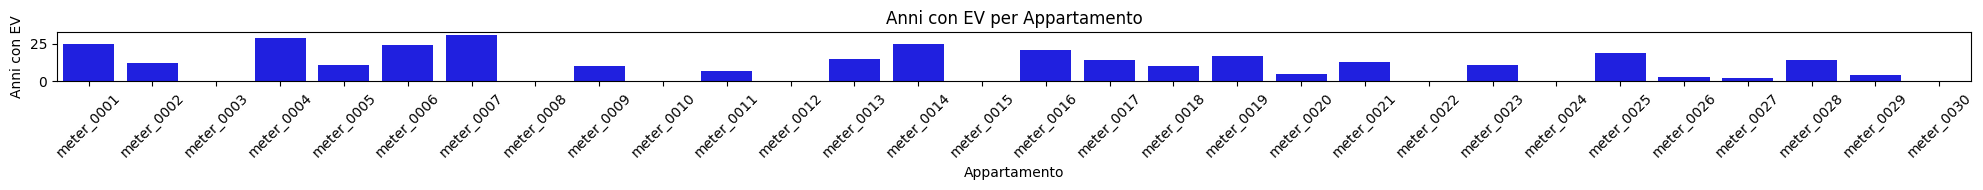

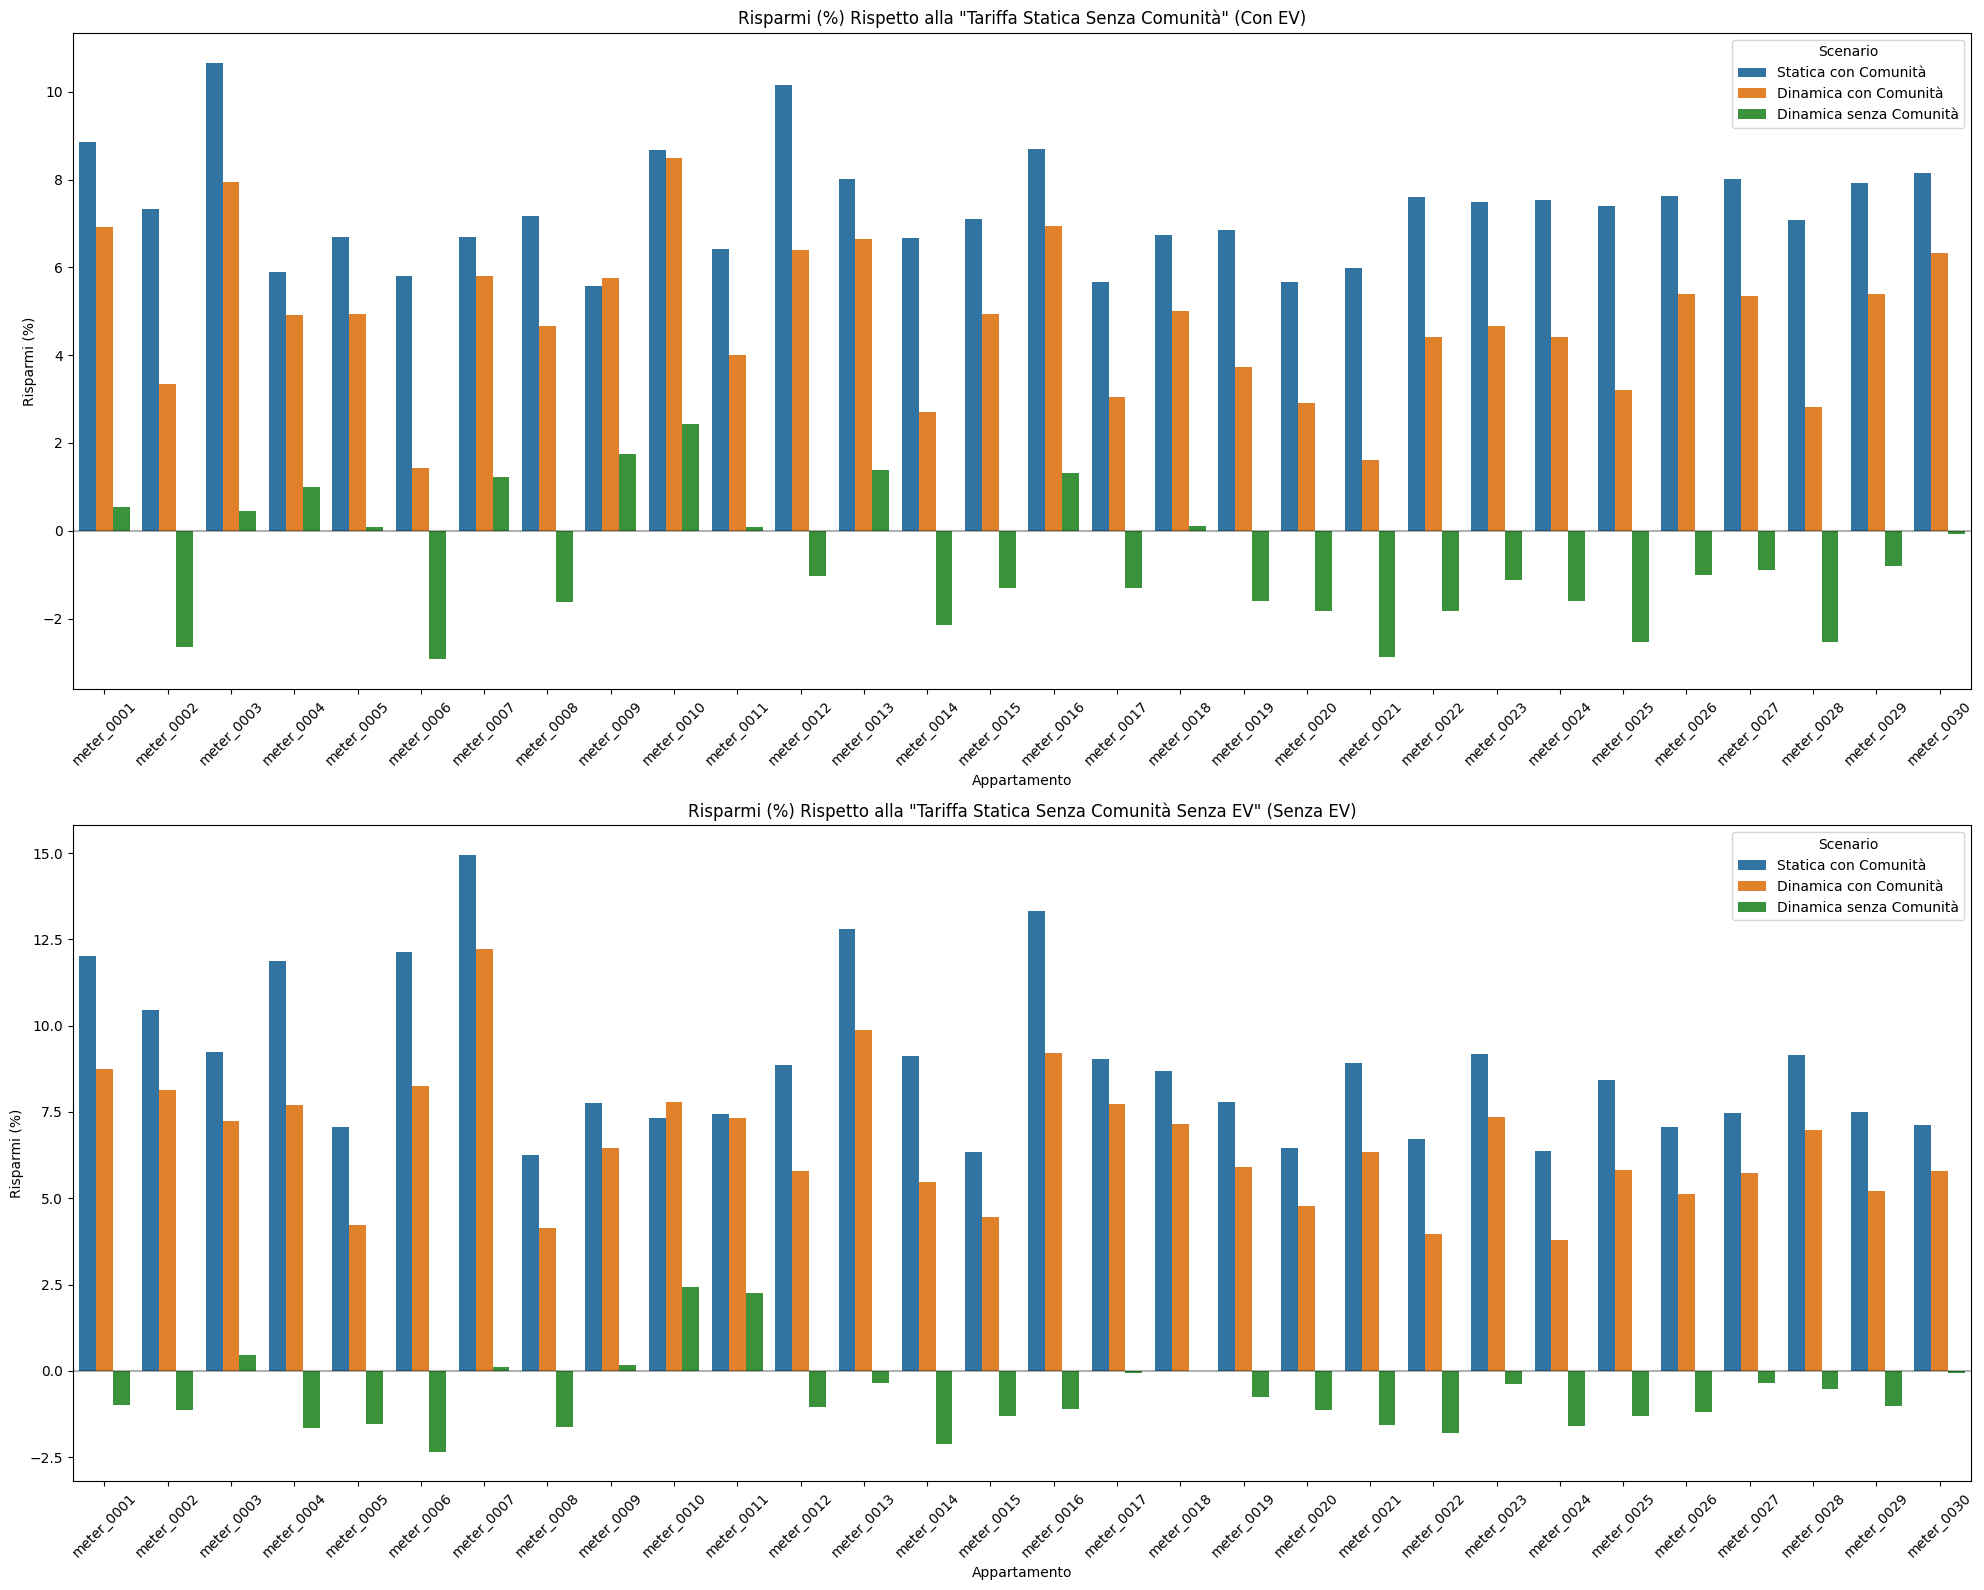

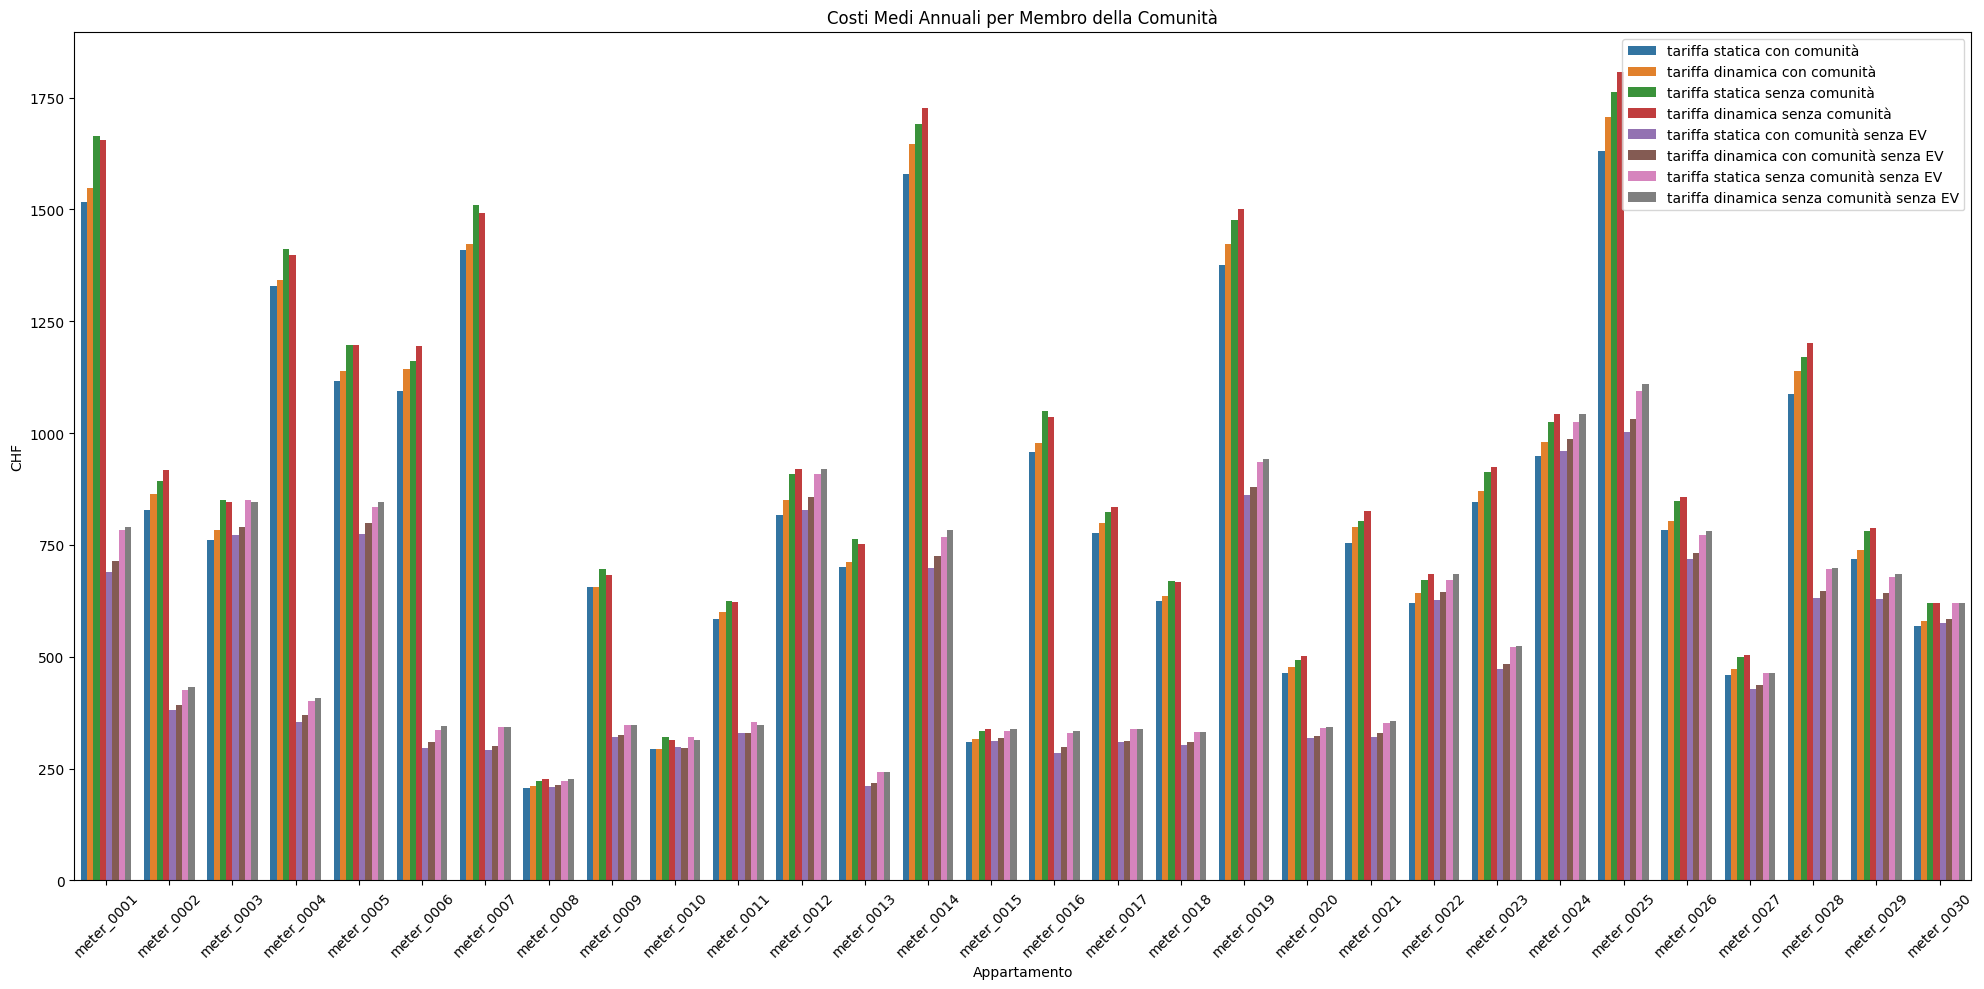

In [8]:
#@title ▶️ Codice per calcolo dei costi per gli inquilini ▶️
self_consumed_energy = np.minimum(production_lifetime, tot_consumption_lifetime_ev)
consumed_energy_users_community = energy_ratio_users * self_consumed_energy.values.reshape(-1, 1)
consumed_energy_users_grid = consumption_lifetime_ev - consumed_energy_users_community

self_consumed_energy_no_ev = np.minimum(production_lifetime, tot_consumption_lifetime)
consumed_energy_users_community_no_ev = energy_ratio_users * self_consumed_energy_no_ev.values.reshape(-1, 1)
consumed_energy_users_grid_no_ev = consumption_lifetime - consumed_energy_users_community_no_ev

costs_users_community = consumed_energy_users_community.sum() * pv_bankability.get_p_sell_com()
costs_users_grid_static = consumed_energy_users_grid.sum() * tariffa_statica / 100
costs_users_grid_dynamic = (consumed_energy_users_grid * tariffa_dinamica.values.reshape(-1, 1) / 100).sum()

costs_users_community_no_ev = consumed_energy_users_community_no_ev.sum() * pv_bankability.get_p_sell_com()
costs_users_grid_static_no_ev = consumed_energy_users_grid_no_ev.sum() * tariffa_statica / 100
costs_users_grid_dynamic_no_ev = (consumed_energy_users_grid_no_ev * tariffa_dinamica.values.reshape(-1, 1) / 100).sum()

costs_users_static_no_community = consumption_lifetime_ev.sum() * tariffa_statica / 100
costs_users_static_no_community.name = 'tariffa statica senza comunità'
costs_users_dynamic_no_community = (consumption_lifetime_ev * tariffa_dinamica.values.reshape(-1, 1) / 100).sum()
costs_users_dynamic_no_community.name = 'tariffa dinamica senza comunità'
costs_users_static = costs_users_community + costs_users_grid_static
costs_users_static.name = 'tariffa statica con comunità'
costs_users_dynamic = costs_users_community + costs_users_grid_dynamic
costs_users_dynamic.name = 'tariffa dinamica con comunità'

costs_users_static_no_community_no_ev = consumption_lifetime.sum() * tariffa_statica / 100
costs_users_static_no_community_no_ev.name = 'tariffa statica senza comunità senza EV'
costs_users_dynamic_no_community_no_ev = (consumption_lifetime * tariffa_dinamica.values.reshape(-1, 1) / 100).sum()
costs_users_dynamic_no_community_no_ev.name = 'tariffa dinamica senza comunità senza EV'
costs_users_static_no_ev = costs_users_community_no_ev + costs_users_grid_static_no_ev
costs_users_static_no_ev.name = 'tariffa statica con comunità senza EV'
costs_users_dynamic_no_ev = costs_users_community_no_ev + costs_users_grid_dynamic_no_ev
costs_users_dynamic_no_ev.name = 'tariffa dinamica con comunità senza EV'


tot_years_ev = (life_span - (meter_assigned_ev[['year_ev_1', 'year_ev_2']]-2025).clip(0).apply(pd.to_numeric, errors='coerce').fillna(life_span)).sum(axis=1)
fig, ax = plt.subplots(figsize=(20, 2))
sns.barplot(x=tot_years_ev.index, y=tot_years_ev.values, color='blue')
ax.set_xlabel('Appartamento')
ax.set_ylabel('Anni con EV')
ax.set_title('Anni con EV per Appartamento')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()


# Calculate percentage savings with respect to reference cases
# First, prepare the data for cases with EV
savings_with_ev = pd.DataFrame(index=costs_users_static.index)
savings_with_ev['Statica con Comunità'] = (1 - costs_users_static / costs_users_static_no_community) * 100
savings_with_ev['Dinamica con Comunità'] = (1 - costs_users_dynamic / costs_users_static_no_community) * 100
savings_with_ev['Dinamica senza Comunità'] = (1 - costs_users_dynamic_no_community / costs_users_static_no_community) * 100

# Second, prepare the data for cases without EV
savings_without_ev = pd.DataFrame(index=costs_users_static_no_ev.index)
savings_without_ev['Statica con Comunità'] = (1 - costs_users_static_no_ev / costs_users_static_no_community_no_ev) * 100
savings_without_ev['Dinamica con Comunità'] = (1 - costs_users_dynamic_no_ev / costs_users_static_no_community_no_ev) * 100
savings_without_ev['Dinamica senza Comunità'] = (1 - costs_users_dynamic_no_community_no_ev / costs_users_static_no_community_no_ev) * 100

# Create a new figure with subplots
fig, ax = plt.subplots(2, 1, figsize=(20, 16))

# Melt DataFrames for seaborn plotting
savings_with_ev_melted = savings_with_ev.reset_index(names='appartamento').melt(
    id_vars='appartamento', var_name='scenario', value_name='risparmi_percentuale')
savings_without_ev_melted = savings_without_ev.reset_index(names='appartamento').melt(
    id_vars='appartamento', var_name='scenario', value_name='risparmi_percentuale')

# Plot for cases with EV
sns.barplot(data=savings_with_ev_melted, x='appartamento', y='risparmi_percentuale', hue='scenario', ax=ax[0], errorbar=None)
ax[0].set_title('Risparmi (%) Rispetto alla "Tariffa Statica Senza Comunità" (Con EV)')
ax[0].set_ylabel('Risparmi (%)')
ax[0].set_xlabel('Appartamento')
ax[0].tick_params(axis='x', rotation=45)
ax[0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax[0].legend(title='Scenario')

# Plot for cases without EV
sns.barplot(data=savings_without_ev_melted, x='appartamento', y='risparmi_percentuale', hue='scenario', ax=ax[1], errorbar=None)
ax[1].set_title('Risparmi (%) Rispetto alla "Tariffa Statica Senza Comunità Senza EV" (Senza EV)')
ax[1].set_ylabel('Risparmi (%)')
ax[1].set_xlabel('Appartamento')
ax[1].tick_params(axis='x', rotation=45)
ax[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax[1].legend(title='Scenario')

plt.tight_layout()


# plot costs using seaborn barplot
df_long = (
    pd.concat([costs_users_static/life_span, costs_users_dynamic/life_span, costs_users_static_no_community/life_span, costs_users_dynamic_no_community/life_span,
               costs_users_static_no_ev/life_span, costs_users_dynamic_no_ev/life_span, costs_users_static_no_community_no_ev/life_span, costs_users_dynamic_no_community_no_ev/life_span],
              axis=1)
      .reset_index(names='appartamento')              # turn index into a column
      .melt(id_vars='appartamento',
            var_name='metric', value_name='value')
)

fig, ax = plt.subplots(figsize=(20, 10))
hue_order = df_long['metric'].unique()

ax = sns.barplot(data=df_long,
                 x='appartamento',     # grouping axis
                 y='value',
                 hue='metric', # gives the two colors/legend entries
                 hue_order=hue_order,
                 errorbar=None # skip CI whiskers (they're off by default ≥ 0.13)
)

ax.set_xlabel('Appartamento')
ax.set_ylabel('CHF')
ax.set_title('Costi Medi Annuali per Membro della Comunità')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 5000})'''))